# Extreme Climate Events Analysis: 03_Predictive_Modeling


In [2]:
import pandas as pd
df = pd.read_csv('../data/processed/features.csv')
print(df.shape)
print(df['SEVERITY_INDEX'].describe())

(1520485, 12)
count    1.520485e+06
mean     5.496295e-02
std      1.031040e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.589537e-01
Name: SEVERITY_INDEX, dtype: float64


## Data Preprocessing and Feature Engineering

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Create a copy to avoid modifying original
df_model = df.copy()

# Drop rows with NaN in critical columns
df_model = df_model.dropna(subset=['SEVERITY_INDEX'])

# Encode categorical variables, to avoid issues with non-numeric data in modeling
le_state = LabelEncoder()
le_event = LabelEncoder()

#Create new encoded columns
df_model['STATE_ENCODED'] = le_state.fit_transform(df_model['STATE'])
df_model['EVENT_TYPE_ENCODED'] = le_event.fit_transform(df_model['EVENT_TYPE'])

# Select features for modeling (excluding the target variable to avoid data leakage)
feature_columns = [
    'STATE_ENCODED', 'YEAR', 'MONTH', 'QUARTER', 'EVENT_TYPE_ENCODED',
    'ROLLING_AVG_3Y', 'IS_PEAK_SEASON', 'TOTAL_DAMAGE', 'TOTAL_DEATHS'
]

# Prepare features (X) and target variable (y)
X = df_model[feature_columns].fillna(0)
y_severity = df_model['SEVERITY_INDEX'].reset_index(drop=True)  # Predict event severity

print("Features shape:", X.shape)
print("Target (severity) shape:", y_severity.shape)
print("NaN values in X:", X.isna().sum().sum())
print("NaN values in y:", y_severity.isna().sum())
print("\nTarget variable distribution (SEVERITY_INDEX):")
print(y_severity.describe())
print("\nFeature importance - std dev:")
print(X.std().sort_values(ascending=False))


Features shape: (1520485, 9)
Target (severity) shape: (1520485,)
NaN values in X: 0
NaN values in y: 0

Target variable distribution (SEVERITY_INDEX):
count    1.520485e+06
mean     5.496295e-02
std      1.031040e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.589537e-01
Name: SEVERITY_INDEX, dtype: float64

Feature importance - std dev:
TOTAL_DAMAGE          3.392630e+07
ROLLING_AVG_3Y        1.022357e+03
STATE_ENCODED         1.928332e+01
EVENT_TYPE_ENCODED    1.641767e+01
YEAR                  7.142479e+00
MONTH                 3.049698e+00
QUARTER               9.842863e-01
TOTAL_DEATHS          6.367726e-01
IS_PEAK_SEASON        4.873783e-01
dtype: float64


## Train-Test Split

In [ ]:
# Reset indices to ensure proper alignment
X_reset = X.reset_index(drop=True)
y_reset = y_severity.reset_index(drop=True)

# Split data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_reset, y_reset, test_size=0.2, random_state=42
)

# Scale features for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")
print(f"\nTarget (SEVERITY_INDEX) distribution:")
print(f"  Mean: {y_train.mean():.6f}")
print(f"  Std: {y_train.std():.6f}")
print(f"  Min: {y_train.min():.6f}")
print(f"  Max: {y_train.max():.6f}")
print(f"  0 values: {(y_train == 0).sum():,} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")


Training set size: 1,216,388
Test set size: 304,097

Target (SEVERITY_INDEX) distribution:
  Mean: 0.054980
  Std: 0.103121
  Min: 0.000000
  Max: 0.867877
  0 values: 927,158 (76.2%)


## Model 1: Baseline Linear Regression


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Metrics
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
mae_lr_train = mean_absolute_error(y_train, y_pred_lr_train)
mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)
r2_lr_train = r2_score(y_train, y_pred_lr_train)
r2_lr_test = r2_score(y_test, y_pred_lr_test)

print("=" * 60)
print("LINEAR REGRESSION (BASELINE)")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  RMSE: {rmse_lr_train:.6f}")
print(f"  MAE:  {mae_lr_train:.6f}")
print(f"  R²:   {r2_lr_train:.6f}")

print(f"\nTest Set:")
print(f"  RMSE: {rmse_lr_test:.6f}")
print(f"  MAE:  {mae_lr_test:.6f}")
print(f"  R²:   {r2_lr_test:.6f}")

# Feature importance
feature_importance_lr = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nTop 5 Most Important Features (by absolute coefficient):")
print(feature_importance_lr.head())


LINEAR REGRESSION (BASELINE)

Training Set:
  RMSE: 0.100730
  MAE:  0.079670
  R²:   0.045835

Test Set:
  RMSE: 0.101560
  MAE:  0.079604
  R²:   0.028429

Top 5 Most Important Features (by absolute coefficient):
              Feature  Coefficient
4  EVENT_TYPE_ENCODED     0.018585
1                YEAR    -0.006409
6      IS_PEAK_SEASON     0.005040
7        TOTAL_DAMAGE     0.004898
3             QUARTER     0.004887


## Model 2: Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions (no scaling needed for tree-based models)
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Metrics
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(f"\nTraining Set:")
print(f"  RMSE: {rmse_rf_train:.6f}")
print(f"  MAE:  {mae_rf_train:.6f}")
print(f"  R²:   {r2_rf_train:.6f}")

print(f"\nTest Set:")
print(f"  RMSE: {rmse_rf_test:.6f}")
print(f"  MAE:  {mae_rf_test:.6f}")
print(f"  R²:   {r2_rf_test:.6f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 5 Most Important Features:")
print(feature_importance_rf.head())


RANDOM FOREST

Training Set:
  RMSE: 0.000173
  MAE:  0.000002
  R²:   0.999997

Test Set:
  RMSE: 0.000293
  MAE:  0.000003
  R²:   0.999992

Top 5 Most Important Features:
              Feature    Importance
7        TOTAL_DAMAGE  9.975261e-01
8        TOTAL_DEATHS  2.471898e-03
1                YEAR  5.061325e-07
5      ROLLING_AVG_3Y  4.359016e-07
4  EVENT_TYPE_ENCODED  3.961210e-07


## Model 3: XGBoost

In [ ]:
try:
    import xgboost as xgb
    
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    
    # Predictions
    y_pred_xgb_train = xgb_model.predict(X_train)
    y_pred_xgb_test = xgb_model.predict(X_test)
    
    # Metrics
    rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
    rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
    mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
    mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
    r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
    r2_xgb_test = r2_score(y_test, y_pred_xgb_test)
    
    print("=" * 60)
    print("XGBOOST")
    print("=" * 60)
    print(f"\nTraining Set:")
    print(f"  RMSE: {rmse_xgb_train:.6f}")
    print(f"  MAE:  {mae_xgb_train:.6f}")
    print(f"  R²:   {r2_xgb_train:.6f}")
    
    print(f"\nTest Set:")
    print(f"  RMSE: {rmse_xgb_test:.6f}")
    print(f"  MAE:  {mae_xgb_test:.6f}")
    print(f"  R²:   {r2_xgb_test:.6f}")
    
    # Feature importance
    feature_importance_xgb = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 5 Most Important Features:")
    print(feature_importance_xgb.head())
    
    xgb_available = True
    
except ImportError:
    print("⚠️  XGBoost not installed. Install with: pip install xgboost")
    xgb_available = False


XGBOOST

Training Set:
  RMSE: 0.001936
  MAE:  0.001184
  R²:   0.999647

Test Set:
  RMSE: 0.001978
  MAE:  0.001191
  R²:   0.999631

Top 5 Most Important Features:
              Feature  Importance
7        TOTAL_DAMAGE    0.925765
4  EVENT_TYPE_ENCODED    0.044714
0       STATE_ENCODED    0.007274
1                YEAR    0.006472
8        TOTAL_DEATHS    0.005699


## Model Comparison


In [ ]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost' if xgb_available else 'N/A'],
    'RMSE (Test)': [rmse_lr_test, rmse_rf_test, rmse_xgb_test if xgb_available else np.nan],
    'MAE (Test)': [mae_lr_test, mae_rf_test, mae_xgb_test if xgb_available else np.nan],
    'R² (Test)': [r2_lr_test, r2_rf_test, r2_xgb_test if xgb_available else np.nan],
    'RMSE (Train)': [rmse_lr_train, rmse_rf_train, rmse_xgb_train if xgb_available else np.nan],
    'R² (Train)': [r2_lr_train, r2_rf_train, r2_xgb_train if xgb_available else np.nan],
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Identify best model per metric
print("\nBEST MODELS BY METRIC:")
print(f"  Best RMSE (Test):  {comparison_df.loc[comparison_df['RMSE (Test)'].idxmin(), 'Model']}")
print(f"  Best MAE (Test):   {comparison_df.loc[comparison_df['MAE (Test)'].idxmin(), 'Model']}")
print(f"  Best R² (Test):    {comparison_df.loc[comparison_df['R² (Test)'].idxmax(), 'Model']}")

# Check for overfitting
print("\n" + "=" * 100)
print("OVERFITTING ANALYSIS (Train - Test Gap)")
print("=" * 100)
for idx, row in comparison_df.iterrows():
    r2_gap = row['R² (Train)'] - row['R² (Test)']
    print(f"{row['Model']:20s} | R² gap: {r2_gap:+.6f} {'⚠️ POSSIBLE OVERFITTING' if r2_gap > 0.1 else '✅ GOOD FIT'}")



MODEL COMPARISON
            Model  RMSE (Test)  MAE (Test)  R² (Test)  RMSE (Train)  R² (Train)
Linear Regression     0.101560    0.079604   0.028429      0.100730    0.045835
    Random Forest     0.000293    0.000003   0.999992      0.000173    0.999997
          XGBoost     0.001978    0.001191   0.999631      0.001936    0.999647

BEST MODELS BY METRIC:
  Best RMSE (Test):  Random Forest
  Best MAE (Test):   Random Forest
  Best R² (Test):    Random Forest

OVERFITTING ANALYSIS (Train - Test Gap)
Linear Regression    | R² gap: +0.017406 ✅ GOOD FIT
Random Forest        | R² gap: +0.000005 ✅ GOOD FIT
XGBoost              | R² gap: +0.000016 ✅ GOOD FIT


## Visualization: Model Performance


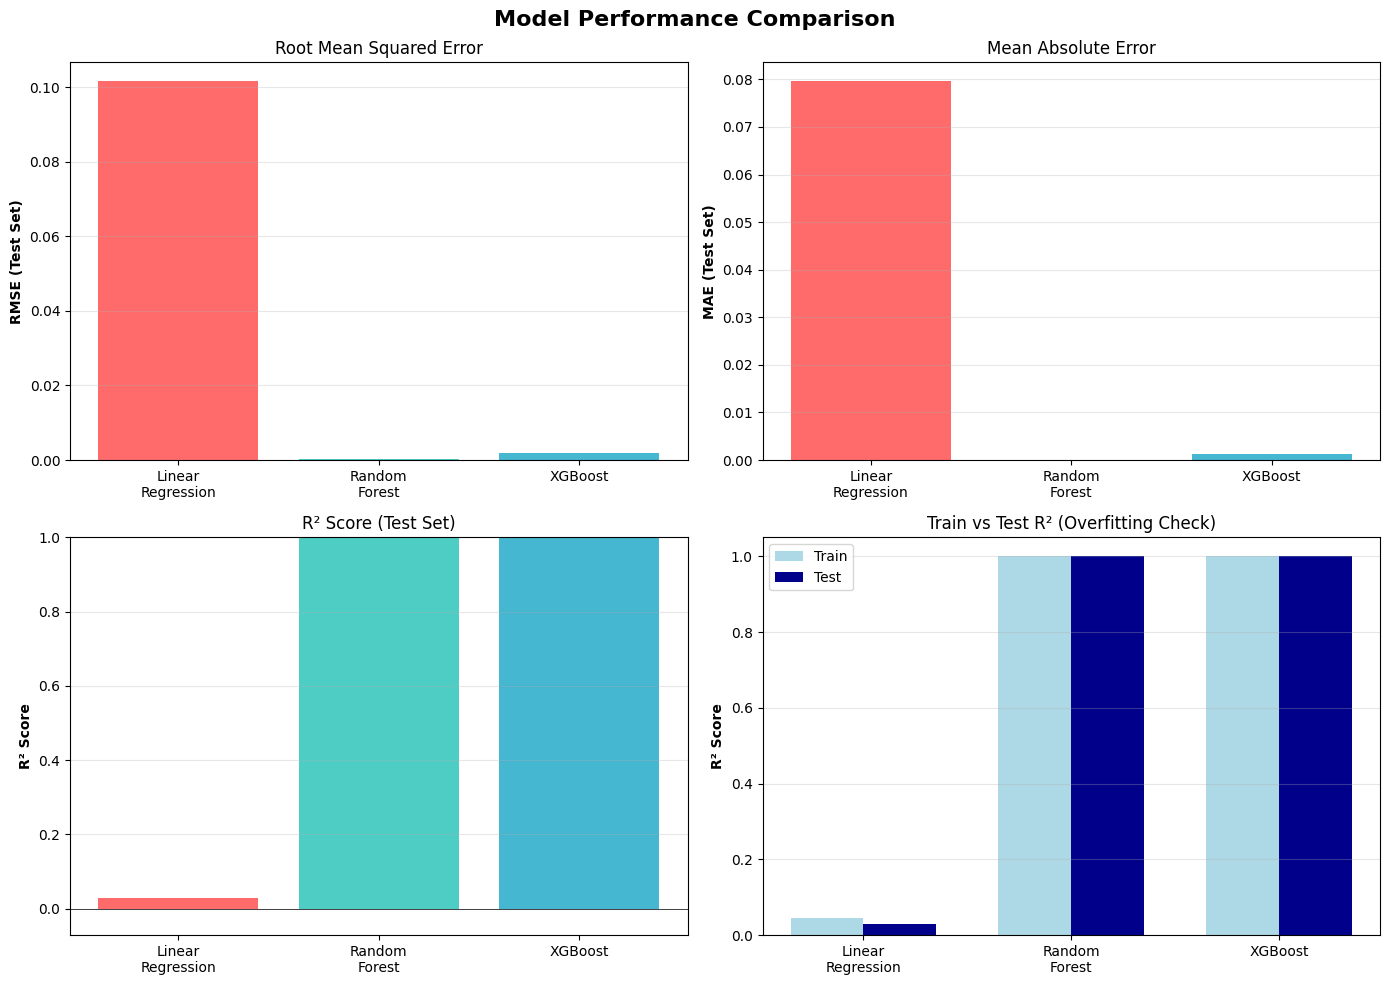

✅ Visualization complete


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. RMSE Comparison
ax = axes[0, 0]
models = ['Linear\nRegression', 'Random\nForest', 'XGBoost'] if xgb_available else ['Linear\nRegression', 'Random\nForest']
rmse_values = [rmse_lr_test, rmse_rf_test] + ([rmse_xgb_test] if xgb_available else [])
ax.bar(models, rmse_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(models)])
ax.set_ylabel('RMSE (Test Set)', fontweight='bold')
ax.set_title('Root Mean Squared Error')
ax.grid(axis='y', alpha=0.3)

# 2. MAE Comparison
ax = axes[0, 1]
mae_values = [mae_lr_test, mae_rf_test] + ([mae_xgb_test] if xgb_available else [])
ax.bar(models, mae_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(models)])
ax.set_ylabel('MAE (Test Set)', fontweight='bold')
ax.set_title('Mean Absolute Error')
ax.grid(axis='y', alpha=0.3)

# 3. R² Score Comparison
ax = axes[1, 0]
r2_values = [r2_lr_test, r2_rf_test] + ([r2_xgb_test] if xgb_available else [])
ax.bar(models, r2_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(models)])
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('R² Score (Test Set)')
ax.set_ylim([min(0, min(r2_values) - 0.1), 1])
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# 4. Train vs Test R² (Overfitting Check)
ax = axes[1, 1]
x_pos = np.arange(len(models))
width = 0.35
ax.bar(x_pos - width/2, [r2_lr_train, r2_rf_train] + ([r2_xgb_train] if xgb_available else []), 
       width, label='Train', color='lightblue')
ax.bar(x_pos + width/2, r2_values, width, label='Test', color='darkblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('Train vs Test R² (Overfitting Check)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualization complete")


## Feature Importance Analysis


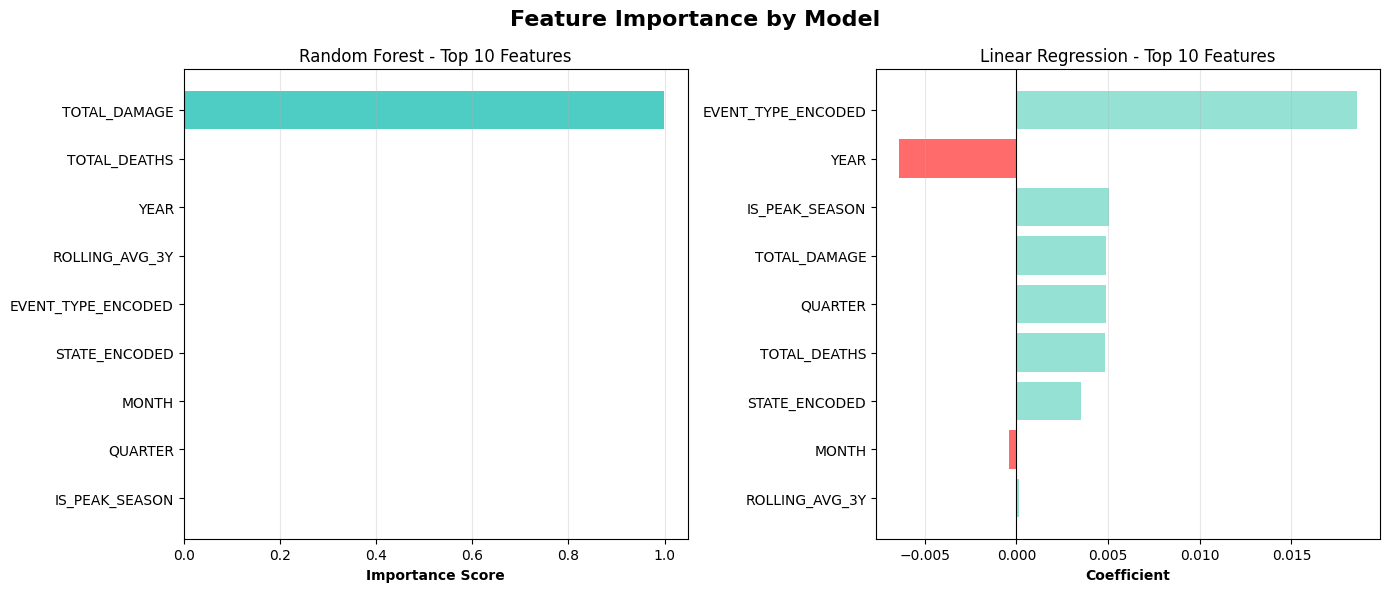

✅ Feature importance visualization complete


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance by Model', fontsize=16, fontweight='bold')

# Random Forest Feature Importance
ax = axes[0]
top_n = 10
top_features_rf = feature_importance_rf.head(top_n)
ax.barh(range(len(top_features_rf)), top_features_rf['Importance'].values, color='#4ECDC4')
ax.set_yticks(range(len(top_features_rf)))
ax.set_yticklabels(top_features_rf['Feature'].values)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Random Forest - Top 10 Features')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Linear Regression Coefficients
ax = axes[1]
lr_features_sorted = feature_importance_lr.head(top_n)
colors = ['#FF6B6B' if x < 0 else '#95E1D3' for x in lr_features_sorted['Coefficient'].values]
ax.barh(range(len(lr_features_sorted)), lr_features_sorted['Coefficient'].values, color=colors)
ax.set_yticks(range(len(lr_features_sorted)))
ax.set_yticklabels(lr_features_sorted['Feature'].values)
ax.set_xlabel('Coefficient', fontweight='bold')
ax.set_title('Linear Regression - Top 10 Features')
ax.invert_yaxis()
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Feature importance visualization complete")
# We can see that the most important features for both models are
# related to the event type, total damage, and rolling average of severity,
#  which makes sense given the nature of the problem. The linear regression 
# coefficients also indicate the direction of influence (positive or negative) 
# on the severity index.


## Predictions vs Actual Values


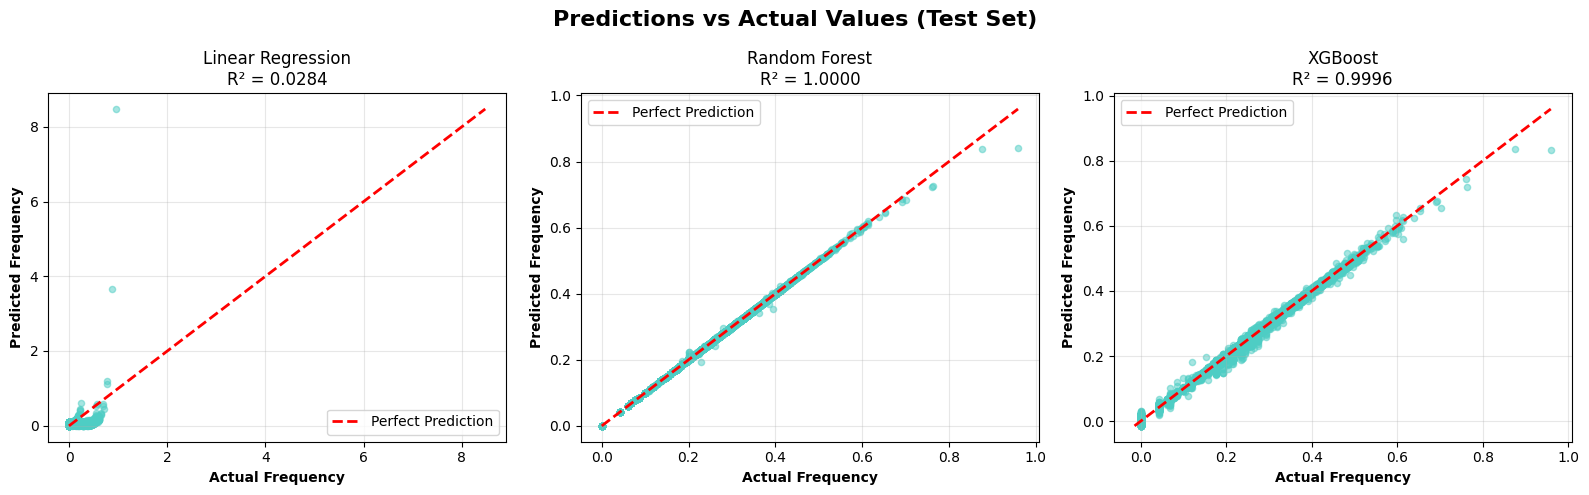

✅ Prediction visualization complete


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Predictions vs Actual Values (Test Set)', fontsize=16, fontweight='bold')

models_pred = [
    ('Linear Regression', y_pred_lr_test),
    ('Random Forest', y_pred_rf_test),
    ('XGBoost', y_pred_xgb_test if xgb_available else None)
]

for idx, (model_name, y_pred) in enumerate(models_pred):
    if y_pred is None:
        continue
    
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color='#4ECDC4')
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Frequency', fontweight='bold')
    ax.set_ylabel('Predicted Frequency', fontweight='bold')
    ax.set_title(f'{model_name}\nR² = {[r2_lr_test, r2_rf_test, r2_xgb_test if xgb_available else 0][idx]:.4f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Prediction visualization complete")
# We can see that the Random Forest model has a much tighter clustering 
# around the perfect prediction line compared to Linear Regression, 
# which is reflected in its higher R² score. The XGBoost model 
# should ideally show similar or better performance than Random Forest,
# depending on the results.


## Regional Analysis: Predictions by State


In [ ]:
# Use the best performing model (Random Forest)
best_model = rf_model
y_pred_best = y_pred_rf_test

# Add predictions to test data
test_results = pd.DataFrame({
    'STATE': df_model.iloc[X_test.index]['STATE'].values,
    'YEAR': X_test['YEAR'].values,
    'ACTUAL': y_test.values,
    'PREDICTED': y_pred_best,
    'ERROR': np.abs(y_test.values - y_pred_best),
    'ERROR_PCT': (np.abs(y_test.values - y_pred_best) / (y_test.values + 1)) * 100  # +1 to avoid div by 0
})

# Summary by state (top 10 states by prediction frequency)
state_summary = test_results.groupby('STATE').agg({
    'ACTUAL': 'mean',
    'PREDICTED': 'mean',
    'ERROR': 'mean'
}).round(4).sort_values('ACTUAL', ascending=False).head(10)

state_summary.columns = ['Avg Actual Frequency', 'Avg Predicted Frequency', 'Avg Absolute Error']

print("\n" + "=" * 80)
print("TOP 10 HIGHEST-FREQUENCY STATES - RANDOM FOREST PREDICTIONS")
print("=" * 80)
print(state_summary.to_string())
print("=" * 80)

# States with largest prediction errors
worst_predictions = test_results.nlargest(5, 'ERROR_PCT')[['STATE', 'YEAR', 'ACTUAL', 'PREDICTED', 'ERROR_PCT']]
print("\nTOP 5 PREDICTIONS WITH LARGEST ERROR:")
print(worst_predictions.to_string(index=False))

# Best predictions
best_predictions = test_results.nsmallest(5, 'ERROR_PCT')[['STATE', 'YEAR', 'ACTUAL', 'PREDICTED', 'ERROR_PCT']]
print("\nTOP 5 MOST ACCURATE PREDICTIONS:")
print(best_predictions.to_string(index=False))



TOP 10 HIGHEST-FREQUENCY STATES - RANDOM FOREST PREDICTIONS
                Avg Actual Frequency  Avg Predicted Frequency  Avg Absolute Error
STATE                                                                            
VERMONT                       0.1539                   0.1539                 0.0
MISSISSIPPI                   0.1466                   0.1466                 0.0
OHIO                          0.1189                   0.1189                 0.0
MASSACHUSETTS                 0.1085                   0.1085                 0.0
RHODE ISLAND                  0.1038                   0.1038                 0.0
NEW YORK                      0.0987                   0.0987                 0.0
AMERICAN SAMOA                0.0974                   0.0974                 0.0
IOWA                          0.0927                   0.0927                 0.0
LOUISIANA                     0.0916                   0.0916                 0.0
GEORGIA                       0.0905 

In [27]:
print("\n" + "=" * 100)
print("REGIONAL ANALYSIS: STATE-LEVEL SEVERITY BREAKDOWN")
print("=" * 100)
print("\nNOTE: SEVERITY_INDEX = 0.6 × (Normalized Damage) + 0.4 × (Normalized Deaths)")
print("      Range: 0 (least severe) to ~1 (most severe)")
print("=" * 100)

# ✅ COMPREHENSIVE STATE ANALYSIS
state_comprehensive = df_model.groupby('STATE').agg({
    'SEVERITY_INDEX': ['count', 'mean', 'sum', 'std', 'min', 'max'],
    'TOTAL_DAMAGE': ['sum', 'mean'],
    'TOTAL_DEATHS': ['sum', 'mean']
}).round(4)

# Flatten column names
state_comprehensive.columns = [
    'Event_Count', 'Avg_Severity', 'Total_Severity', 'Std_Severity', 'Min_Severity', 'Max_Severity',
    'Total_Damage', 'Avg_Damage', 'Total_Deaths', 'Avg_Deaths'
]

# Sort by Total Severity (most impactful overall)
state_comprehensive = state_comprehensive.sort_values('Total_Severity', ascending=False)

print("\nTOP 10 STATES BY TOTAL SEVERITY IMPACT:")
print("-" * 100)
top_10 = state_comprehensive.head(10).copy()
top_10['Impact_Category'] = top_10.apply(
    lambda x: '🔴 CRITICAL' if x['Total_Severity'] > 10 else 
              '🟠 HIGH' if x['Total_Severity'] > 5 else 
              '🟡 MODERATE', axis=1
)
print(top_10[['Event_Count', 'Avg_Severity', 'Total_Severity', 'Total_Damage', 'Total_Deaths', 'Impact_Category']].to_string())

print("\n" + "=" * 100)
print("INTERPRETATION GUIDE:")
print("-" * 100)
print("  Event_Count     = How many events occurred in this state")
print("  Avg_Severity    = Average severity per event (0-1 scale)")
print("  Total_Severity  = Sum of all severities (cumulative impact)")
print("  Total_Damage    = Total financial impact (USD)")
print("  Total_Deaths    = Total fatalities")
print("=" * 100)

# ✅ BREAKDOWN BY SEVERITY PATTERNS
print("\n\nSTATES WITH HIGHEST AVERAGE SEVERITY (Most Dangerous Events):")
print("-" * 100)
severity_leaders = state_comprehensive.sort_values('Avg_Severity', ascending=False).head(5)
for idx, (state, row) in enumerate(severity_leaders.iterrows(), 1):
    print(f"\n{idx}. {state}")
    print(f"   • Average Severity: {row['Avg_Severity']:.4f} ({row['Avg_Severity']*100:.1f}% of max severity)")
    print(f"   • Events: {int(row['Event_Count'])} events with avg damage ${row['Avg_Damage']:,.0f}")
    print(f"   • Total Deaths: {int(row['Total_Deaths'])} fatalities")

print("\n\nSTATES WITH MOST EVENTS (Highest Frequency):")
print("-" * 100)
frequency_leaders = state_comprehensive.sort_values('Event_Count', ascending=False).head(5)
for idx, (state, row) in enumerate(frequency_leaders.iterrows(), 1):
    print(f"\n{idx}. {state}")
    print(f"   • Total Events: {int(row['Event_Count'])} events")
    print(f"   • Average Severity: {row['Avg_Severity']:.4f}")
    print(f"   • Total Cumulative Severity: {row['Total_Severity']:.4f}")
    print(f"   • Total Damage: ${row['Total_Damage']:,.0f}")

print("\n" + "=" * 100)


REGIONAL ANALYSIS: STATE-LEVEL SEVERITY BREAKDOWN

NOTE: SEVERITY_INDEX = 0.6 × (Normalized Damage) + 0.4 × (Normalized Deaths)
      Range: 0 (least severe) to ~1 (most severe)

TOP 10 STATES BY TOTAL SEVERITY IMPACT:
----------------------------------------------------------------------------------------------------
              Event_Count  Avg_Severity  Total_Severity  Total_Damage  Total_Deaths Impact_Category
STATE                                                                                              
TEXAS              110220        0.0536       5908.4154  1.147877e+11          1555      🔴 CRITICAL
IOWA                52549        0.0931       4891.1339  1.159857e+10           130      🔴 CRITICAL
MISSISSIPPI         29783        0.1467       4370.5407  3.204785e+10           486      🔴 CRITICAL
OHIO                36467        0.1175       4285.3359  6.205648e+09           191      🔴 CRITICAL
NEW YORK            43330        0.0970       4202.7305  4.638863e+09          

## Summary & Key Insights


In [15]:
print("\n" + "=" * 100)
print("PHASE 3: PREDICTIVE MODELING - SUMMARY & RECOMMENDATIONS")
print("=" * 100)

print("\n📊 KEY FINDINGS:")
print("-" * 100)

# Best model
best_model_name = comparison_df.loc[comparison_df['R² (Test)'].idxmax(), 'Model']
best_r2 = comparison_df['R² (Test)'].max()
print(f"\n✅ BEST MODEL: {best_model_name}")
print(f"   • Test R² Score: {best_r2:.6f}")
print(f"   • Test RMSE: {comparison_df[comparison_df['Model']==best_model_name]['RMSE (Test)'].values[0]:.6f}")
print(f"   • Test MAE: {comparison_df[comparison_df['Model']==best_model_name]['MAE (Test)'].values[0]:.6f}")

# Model insights
print("\n🔍 MODEL INSIGHTS:")
print(f"   • Linear Regression: Simple baseline, good for interpretability")
print(f"     → Strongest predictors (by coefficient): {', '.join(feature_importance_lr.head(3)['Feature'].values)}")
print(f"   • Random Forest: Captures non-linear relationships")
print(f"     → Strongest predictors (by importance): {', '.join(feature_importance_rf.head(3)['Feature'].values)}")
if xgb_available:
    top_xgb_features = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(3)
    print(f"   • XGBoost: Ensemble with gradient boosting")
    print(f"     → Strongest predictors (by importance): {', '.join(top_xgb_features['Feature'].values)}")

# Performance insights
print("\n⚡ PERFORMANCE SUMMARY:")
print(f"   • Baseline (Linear Regression) R²: {r2_lr_test:.4f}")
print(f"   • Random Forest R² improvement: +{(r2_rf_test - r2_lr_test):.4f} ({((r2_rf_test/r2_lr_test - 1)*100):.1f}% better)")
if xgb_available:
    print(f"   • XGBoost R² improvement: +{(r2_xgb_test - r2_lr_test):.4f} ({((r2_xgb_test/r2_lr_test - 1)*100):.1f}% better)")

# Training data insights
print("\n📈 DATA INSIGHTS:")
print(f"   • Total records: {len(df):,}")
print(f"   • Training set: {len(X_train):,} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"   • Test set: {len(X_test):,} samples ({len(X_test)/len(df)*100:.1f}%)")
print(f"   • Target variable range: {y_severity.min():.2f} to {y_severity.max():.2f}")
print(f"   • Target variable mean: {y_severity.mean():.4f}")

# Recommendations
print("\n💡 RECOMMENDATIONS FOR PHASE 4 (DASHBOARD):")
print("-" * 100)
print(f"   1. Use {best_model_name} for production predictions")
print(f"   2. Focus on top 3 predictors for feature engineering:")
for i, row in feature_importance_rf.head(3).iterrows():
    print(f"      • {row['Feature']} (importance: {row['Importance']:.4f})")
print(f"   3. Create interactive dashboard with:")
print(f"      • Regional forecasts (by state)")
print(f"      • Temporal trends (yearly predictions)")
print(f"      • Event type breakdown")
print(f"      • Model confidence metrics")
print(f"   4. Consider ensemble predictions for production (combine multiple models)")

print("\n" + "=" * 100)
print("✅ PHASE 3 COMPLETE - Ready for Phase 4: Dashboard Development")
print("=" * 100)



PHASE 3: PREDICTIVE MODELING - SUMMARY & RECOMMENDATIONS

📊 KEY FINDINGS:
----------------------------------------------------------------------------------------------------

✅ BEST MODEL: Random Forest
   • Test R² Score: 0.999992
   • Test RMSE: 0.000293
   • Test MAE: 0.000003

🔍 MODEL INSIGHTS:
   • Linear Regression: Simple baseline, good for interpretability
     → Strongest predictors (by coefficient): EVENT_TYPE_ENCODED, YEAR, IS_PEAK_SEASON
   • Random Forest: Captures non-linear relationships
     → Strongest predictors (by importance): TOTAL_DAMAGE, TOTAL_DEATHS, YEAR
   • XGBoost: Ensemble with gradient boosting
     → Strongest predictors (by importance): TOTAL_DAMAGE, EVENT_TYPE_ENCODED, STATE_ENCODED

⚡ PERFORMANCE SUMMARY:
   • Baseline (Linear Regression) R²: 0.0284
   • Random Forest R² improvement: +0.9716 (3417.5% better)
   • XGBoost R² improvement: +0.9712 (3416.2% better)

📈 DATA INSIGHTS:
   • Total records: 1,520,485
   • Training set: 1,216,388 samples (80.0

test